# Feature Scaling and Regression

In the previous notebook, we implemented linear regression from scratch using gradient descent.

We tested our implementation on small datasets and learned how multiple features can be handled using matrix operations.

Now we will apply our implementation to the California Housing dataset.

Before doing that, we need to understand **feature scaling** and why it is important for gradient descent.

In this notebook, we will:

1. Understand why features with different scales can cause problems.
2. Learn standardization mathematically.
3. Scale the California Housing features.
4. Train our from-scratch regression model using gradient descent.
5. Observe its convergence.
6. Make predictions on the test data.
7. Evaluate our model.
8. Compare it with our earlier Scikit-learn baseline.

## Why Do We Need Feature Scaling?

Our California Housing dataset contains features that have very different numerical ranges.

For example:

- `MedInc` represents median income and has relatively small values.
- `Population` can have values in the thousands.
- `Latitude` and `Longitude` are around 30–40 and -120.
- `AveOccup` can contain very large values.

Gradient descent calculates the gradient using the feature values.

Therefore, when one feature has values much larger than another feature, it can produce a much larger gradient and cause gradient descent to behave inefficiently.

Before changing anything, we should look at the actual ranges of our training features.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Load the California Housing Dataset

We will use the same California Housing dataset that we explored in the first notebook.

The target variable is the median house value, while the eight numerical features are used as inputs to our regression model.

In [3]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


In [7]:
def gradient_descent(X, y, learning_rate = 0.01, iterations = 1000):

    #Initialize weights and bias
    w = np.zeros(X.shape[1])
    b = 0.0

    mse_history = []

    for i in range(iterations):

        #Calculate predictions
        y_pred = X @ w + b

        #Calculate error
        error = y - y_pred

        #Calculate gradients
        dw = (-2 / len(X)) * X.T @ error
        db = (-2 / len(X)) * np.sum(error)

        #Update weights and bias
        w = w - learning_rate * dw
        b = b - learning_rate * db

        #Calculate and store MSE
        mse = np.mean(error ** 2)
        mse_history.append(mse)

    return w, b, mse_history

In [8]:
def predict(X, w, b):
    return X @ w + b

## Inspecting Feature Scales

Before applying feature scaling, we first need to understand the numerical ranges of our features.

Gradient descent uses feature values when calculating the gradients. If one feature has values that are much larger than another feature, it can have a much stronger influence on the size of the gradient.

We will inspect the training data to see how different the feature scales actually are.

In [9]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,16512.0,3.880754,1.904294,0.499900,2.566700,3.545800,4.773175,15.000100
HouseAge,16512.0,28.608285,12.602499,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,16512.0,5.435235,2.387375,0.888889,4.452055,5.235874,6.061037,141.909091
AveBedrms,16512.0,1.096685,0.433215,0.333333,1.006508,1.049286,1.100348,25.636364
Population,16512.0,1426.453004,1137.056380,3.000000,789.000000,1167.000000,1726.000000,35682.000000
AveOccup,16512.0,3.096961,11.578744,0.692308,2.428799,2.817240,3.280000,1243.333333
Latitude,16512.0,35.643149,2.136665,32.550000,33.930000,34.260000,37.720000,41.950000
Longitude,16512.0,-119.582290,2.005654,-124.350000,-121.810000,-118.510000,-118.010000,-114.310000


## Standardization

One common way to scale numerical features is standardization.

Standardization transforms a feature so that its values are centered around 0 and measured in terms of standard deviations.

The formula is:

$$
z = \frac{x-\mu}{\sigma}
$$

where:

- $x$ is the original feature value.
- $\mu$ is the mean of that feature.
- $\sigma$ is the standard deviation of that feature.
- $z$ is the standardized value.

After standardization, features with very different original scales can be represented on a more comparable scale.

### Standardizing One Feature Manually

We will first standardize the `Population` feature ourselves instead of using a library.

From the training data:

$$
\mu = 1426.453004
$$

and:

$$
\sigma = 1137.056380
$$

For every population value, we calculate:

$$
z = \frac{x-\mu}{\sigma}
$$

This subtracts the mean, which centers the feature around 0, and then divides by the standard deviation, which puts the values on a comparable scale.

In [10]:
population_mean = X_train["Population"].mean()
population_std = X_train["Population"].std()

population_scaled = (
    X_train["Population"] - population_mean
) / population_std;

population_scaled.head()

14196    0.768253
8267    -0.098898
17445   -0.449804
14265   -0.007434
2271    -0.485862
Name: Population, dtype: float64

In [11]:
X_train["Population"].head()

14196    2300.0
8267     1314.0
17445     915.0
14265    1418.0
2271      874.0
Name: Population, dtype: float64

In [12]:
print("Mean", population_scaled.mean())
print("Standard Deviation", population_scaled.std())

Mean -8.606380035853927e-19
Standard Deviation 0.9999999999999999


In [13]:
X_train_scaled = (X_train - X_train.mean()) / X_train.std()
X_test_scaled = (X_test - X_train.mean()) / X_train.std()

X_train_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,-0.326186,0.348480,-0.174911,-0.208359,0.768253,0.051375,-1.372770,1.272548
8267,-0.035842,1.618069,-0.402823,-0.128526,-0.098898,-0.117359,-0.876669,0.709141
17445,0.144697,-1.952651,0.088213,-0.257530,-0.449804,-0.032279,-0.460133,-0.447590
14265,-1.017834,0.586528,-0.599997,-0.145152,-0.007434,0.077505,-1.382130,1.232661
2271,-0.171483,1.141973,0.348997,0.086622,-0.485862,-0.068830,0.532068,-0.108548


In [14]:
X_test_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,-1.155050,-0.286315,-0.520670,-0.171741,-0.030300,0.067406,0.195094,0.285339
3024,-0.708638,0.110432,-0.165810,0.223465,0.121847,-0.036029,-0.235483,0.060973
15663,-0.210395,1.856117,-0.610746,0.205886,-0.102416,-0.149984,1.009447,-1.424827
20484,0.975084,-0.921110,0.305106,-0.176547,0.244972,0.030010,-0.637980,0.429930
9814,-0.081791,0.427829,0.024192,-0.158460,-0.319644,-0.052969,0.457185,-1.170546


In [15]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_scaled shape: (16512, 8)
X_test_scaled shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


## Training on the California Housing Dataset

We can now use our from-scratch gradient descent implementation on the real California Housing dataset.

The training features have been standardized so that the different features are on comparable scales.

We will train the model using the standardized training data and learn:

- 8 weights, one for each feature
- 1 bias

The model will repeatedly update these parameters to minimize the Mean Squared Error.

In [16]:
w, b, mse_history = gradient_descent(
    X_train_scaled.values,
    y_train.values,
    learning_rate=0.01,
    iterations=1000
)

In [17]:
print("Weights:", w)
print("Bias:", b)
print("Final MSE:", mse_history[-1])

Weights: [ 0.85808472  0.15016179 -0.25253734  0.28100672  0.0071106  -0.04344362
 -0.68322257 -0.65415532]
Bias: 2.0719469338918617
Final MSE: 0.5246185477043834


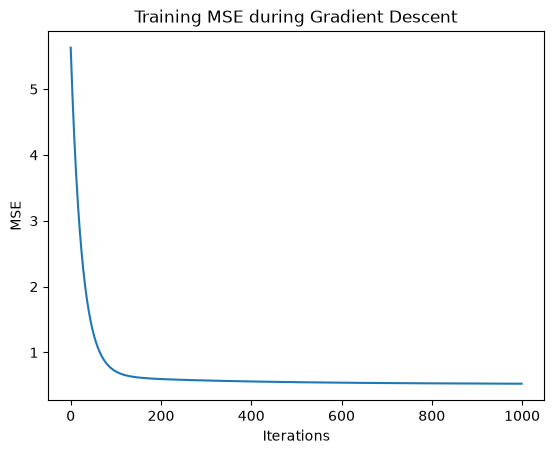

In [18]:
plt.plot(mse_history)
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.title("Training MSE during Gradient Descent")
plt.show()

## Making Predictions on the Test Data

The model has now learned its weights and bias from the training data.

We can use these learned parameters to make predictions for houses that the model has never seen during training.

We will use the standardized test features and the learned weights:

$$
\hat{y} = Xw + b
$$

The test data is kept separate from training so that we can evaluate how well the model generalizes to unseen data.

In [19]:
y_pred = predict(
    X_test_scaled,
    w,
    b
)

In [20]:
print(y_pred[:10])

20046    0.797959
3024     1.708560
15663    2.630388
20484    2.798754
9814     2.468757
13311    2.053986
7113     2.664446
7668     2.172797
18246    2.573559
5723     3.991592
dtype: float64


In [21]:
print(y_test[:10])

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
13311    1.58700
7113     1.98200
7668     1.57500
18246    3.40000
5723     4.46600
Name: MedHouseVal, dtype: float64


## Evaluating the Model

Making predictions is not enough. We need numerical metrics to measure how well our model performs on unseen test data.

We will calculate:

- MAE: average absolute prediction error.
- MSE: average squared prediction error.
- RMSE: square root of MSE, which puts the error back in the target's original units.
- R²: the proportion of variation in house values explained by our model.

In [22]:
mae = np.mean(np.abs(y_test.values - y_pred))

mse = np.mean((y_test.values - y_pred) ** 2)

rmse = np.sqrt(mse)

r2 = 1 - (
    np.sum((y_test.values - y_pred) ** 2)
    /
    np.sum((y_test.values - y_test.values.mean()) ** 2)
)

In [23]:
print("MAE:", mae)
print("MSE", mse)
print("RMSE:", rmse)
print("R2:", r2) 

MAE: 0.5352075133719415
MSE 0.5545797492719158
RMSE: 0.7447011140530916
R2: 0.5767888052656762


## Comparing with Scikit-learn

Our from-scratch gradient descent model produces evaluation metrics that are very close to the Scikit-learn LinearRegression model from the previous notebook.

This confirms that our implementation of linear regression and gradient descent is working correctly.

The small differences occur because our model uses iterative gradient descent with a fixed learning rate and number of iterations, while Scikit-learn's LinearRegression solves the Ordinary Least Squares problem directly.

This experiment also demonstrates why feature scaling is useful for gradient descent: it puts the features on comparable scales, allowing gradient descent to converge effectively.

## Interpreting the Learned Weights

Because we standardized all features before training, the learned weights can be compared more meaningfully.

Each weight represents the expected change in the predicted target when its corresponding feature increases by one standard deviation, while the other features remain fixed.

A larger absolute weight indicates that the feature has a stronger influence on the predictions within this linear model.

This should not be interpreted as causation.

In [24]:
weights = pd.Series(w, index=X_train.columns)

weights.sort_values(ascending=False)

MedInc        0.858085
AveBedrms     0.281007
HouseAge      0.150162
Population    0.007111
AveOccup     -0.043444
AveRooms     -0.252537
Longitude    -0.654155
Latitude     -0.683223
dtype: float64

In [25]:
weights.sort_values()

Latitude     -0.683223
Longitude    -0.654155
AveRooms     -0.252537
AveOccup     -0.043444
Population    0.007111
HouseAge      0.150162
AveBedrms     0.281007
MedInc        0.858085
dtype: float64

In [26]:
y_train_pred = predict(
    X_train_scaled.values,
    w,
    b
)

final_train_mse = np.mean(
    (y_train.values - y_train_pred) ** 2
)

print("Final Training MSE:", final_train_mse)

Final Training MSE: 0.5245992071567778


## Training vs Test Performance

We evaluate the model on both the training and test data.

Training performance tells us how well the model fits the data it learned from.

Test performance tells us how well the model generalizes to unseen data.

A small difference between the two suggests that the model is not dramatically overfitting the training data.

In [29]:
train_mae = np.mean(np.abs(y_train.values - y_train_pred))
train_mse = np.mean((y_train.values - y_train_pred) ** 2)
train_rmse = np.sqrt(train_mse)

train_r2 = 1 - (
    np.sum((y_train.values - y_train_pred) ** 2)
    /
    np.sum((y_train.values - y_train.values.mean()) ** 2)
)

In [30]:
print("Training MAE:", train_mae)
print("Training MSE:", train_mse)
print("Training RMSE:", train_rmse)
print("Training R²:", train_r2)

print("\nTest MAE:", mae)
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test R²:", r2)

Training MAE: 0.5306769143359874
Training MSE: 0.5245992071567778
Training RMSE: 0.7242922111667208
Training R²: 0.6075645140456448

Test MAE: 0.5352075133719415
Test MSE: 0.5545797492719158
Test RMSE: 0.7447011140530916
Test R²: 0.5767888052656762


## Conclusion

In this notebook, we applied our from-scratch linear regression implementation to the California Housing dataset.

We first standardized the features because they were measured on very different scales. We then trained the model using gradient descent and used the learned parameters to make predictions on unseen test data.

The resulting metrics were very close to those obtained using Scikit-learn's LinearRegression model. This provides evidence that our implementation of linear regression and gradient descent is working correctly.

The test R² of approximately 0.577 shows that the linear model explains about 57.7% of the variation in house values. The remaining variation suggests that a simple linear model cannot capture all the patterns present in the dataset.

In the next stage, we will investigate ways to improve the model and determine whether a more flexible machine learning algorithm can capture patterns that linear regression misses.